# t-SNE
This notebook uses **t-SNE** and **KMeans** to explore if we find clusters of items in the data.

In [1]:
### 0) IMPORTS
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from src.reading_data import create_final_dfs
from src.visualizations import apply_paper_style, OCEAN_COLS, IMPACT_SIX
from src.clustering import (
    prepare_item_matrix,
    prepare_trait_matrix,
    run_pca,
    pca_loadings,
    run_tsne,
    silhouette_sweep,
    assign_kmeans,
    assign_hierarchical,
    plot_scree,
    plot_pca_biplot,
    plot_tsne,
    plot_silhouette_sweep,
    plot_dendrogram,
    plot_cluster_trait_profiles,
    plot_cluster_metadata_breakdown,
    OCEAN_LABELS,
    BFI44_FACETS
)

os.makedirs('doc/figs', exist_ok=True)
apply_paper_style()

In [2]:
### 1) LOAD DATA
df_all, df_A, df_B, df_cfa, df_cfa_soc_des, df_metadata, df_lmm, _ = create_final_dfs()


Created dataframes:
df_all:      (141590, 16)
df_A:        (14160, 18)
df_B:        (240, 7)
df_cfa:      (240, 44)
df_cfa_soc_des: (240, 59)
df_metadata: (240, 22)
df_lmm:      (104366, 11)
df_lmm_key:      (104366, 13)


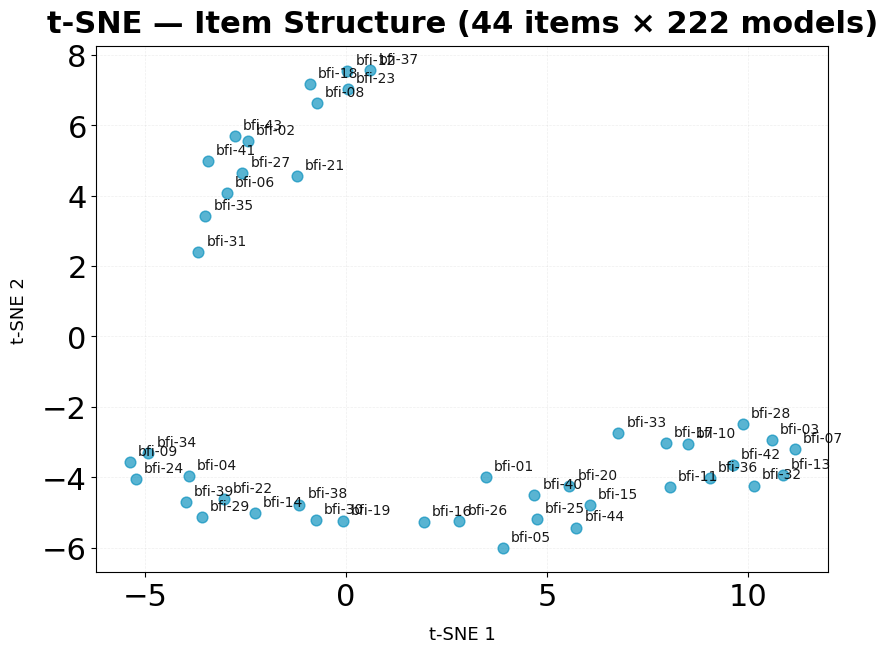

In [3]:
# df_cfa: (222, 44) — rows=models, cols=items
# Transpose so rows=items, cols=model responses
X_items = df_cfa.T.values  # shape (44, 222)
item_labels = df_cfa.columns.tolist()  # 44 item names

embedding = run_tsne(X_items, perplexity=10)  # low perplexity for N=44
fig = plot_tsne(embedding, model_labels=item_labels, annotate=True,
                title="t-SNE — Item Structure (44 items × 222 models)")

In [4]:
X_items

array([[3.3       , 3.3       , 3.22222222, ..., 4.        , 3.8       ,
        2.5       ],
       [2.6       , 3.2       , 3.7       , ..., 4.5       , 4.        ,
        3.9       ],
       [4.3       , 3.6       , 2.7       , ..., 5.        , 5.        ,
        5.        ],
       ...,
       [3.4       , 3.        , 3.5       , ..., 5.        , 5.        ,
        5.        ],
       [3.3       , 2.7       , 3.11111111, ..., 5.        , 4.1       ,
        4.2       ],
       [3.7       , 3.6       , 3.3       , ..., 5.        , 4.2       ,
        4.7       ]], shape=(44, 240))

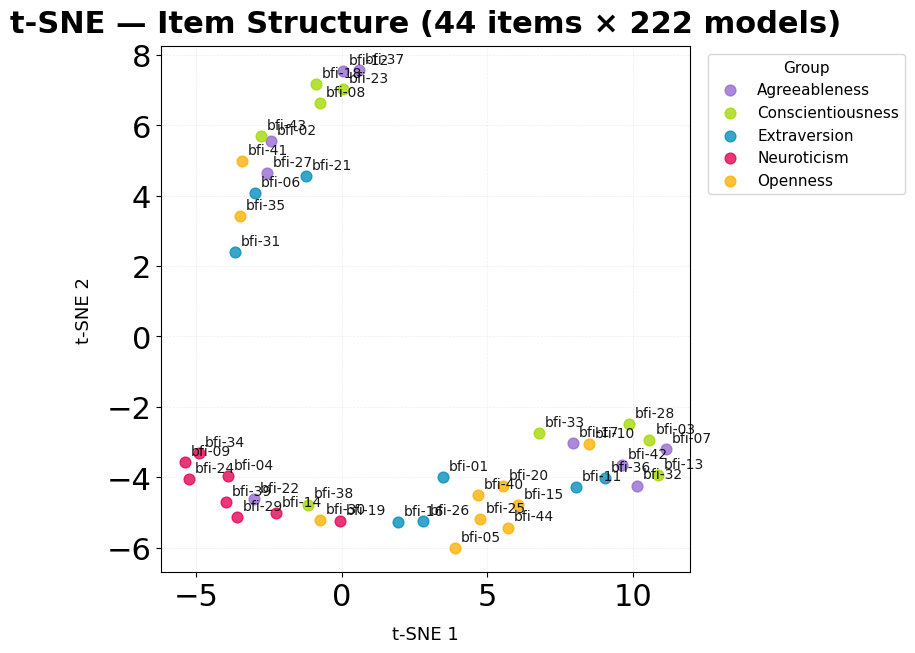

In [5]:
facets = ["Extraversion", "Agreeableness", "Conscientiousness", "Neuroticism", "Openness"]
color_map = {fac: IMPACT_SIX[i] for i, fac in enumerate(facets)}

item_facets = [BFI44_FACETS[label] for label in item_labels]

embedding = run_tsne(X_items, perplexity=10)
fig = plot_tsne(embedding, model_labels=item_labels,
                color_col=item_facets,
                color_map=color_map,
                annotate=True,
                title="t-SNE — Item Structure (44 items × 222 models)")

k=2  silhouette=0.540
k=3  silhouette=0.661
k=4  silhouette=0.648
k=5  silhouette=0.614
k=6  silhouette=0.579

Best k=3 (silhouette=0.661)


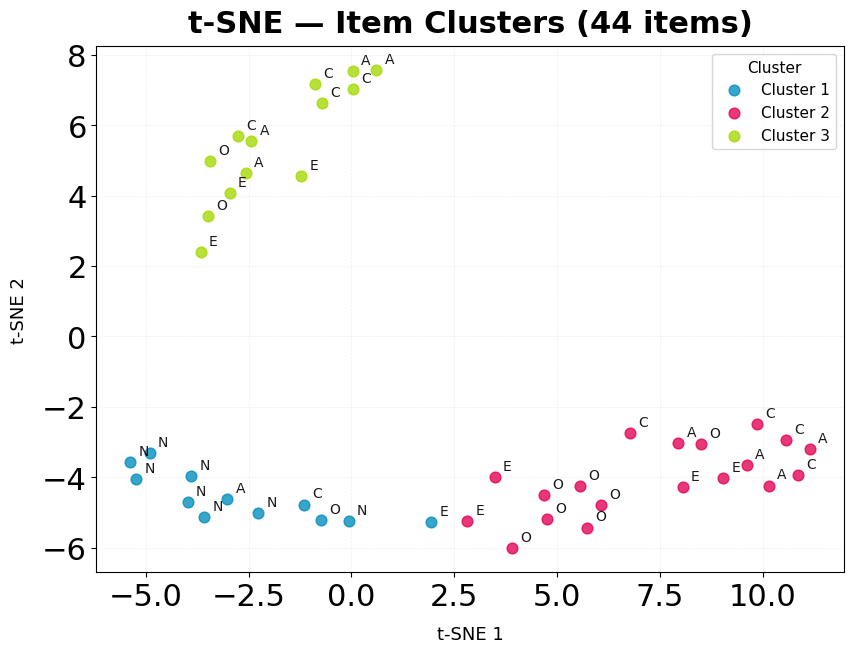

In [18]:
# Test k=2,3,4
sil_scores = {}

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10, init='random')
    labels = km.fit_predict(embedding)
    sil_scores[k] = silhouette_score(embedding, labels)
    print(f"k={k}  silhouette={sil_scores[k]:.3f}")

# best k
best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest k={best_k} (silhouette={sil_scores[best_k]:.3f})")

# Fit best k
km = KMeans(n_clusters=best_k, random_state=42, n_init=10, init='random')
cluster_labels = km.fit_predict(embedding)

# plot_labels = [OCEAN_LABELS.get(lbl, lbl) for lbl in item_labels]

OCEAN_LETTERS = {
    "Extraversion": "E",
    "Agreeableness": "A",
    "Conscientiousness": "C",
    "Neuroticism": "N",
    "Openness": "O",
}

plot_labels = [
    OCEAN_LETTERS[BFI44_FACETS[label]]
    for label in item_labels
]

fig = plot_tsne(embedding, model_labels=plot_labels,
                cluster_labels=cluster_labels,
                annotate=True,
                title="t-SNE — Item Clusters (44 items)")

In [8]:
df_clusters = pd.DataFrame({
    "item": item_labels,
    "facet": item_facets,
    "cluster": cluster_labels
})
print(df_clusters.groupby(["cluster", "facet"]).size())

cluster  facet            
0        Agreeableness        4
         Conscientiousness    4
         Extraversion         3
         Openness             2
1        Agreeableness        4
         Conscientiousness    4
         Extraversion         4
         Openness             7
2        Agreeableness        1
         Conscientiousness    1
         Extraversion         1
         Neuroticism          8
         Openness             1
dtype: int64


In [9]:
with open("../../dat/00_inventories/bfi-llm.json", "r") as f:
    bfi_json = json.load(f)

# Build lookup: item number -> text
item_text = {f"bfi-{item['id']:02d}": item["text"] for item in bfi_json["items"]}

# Print items per cluster
for cluster_id in sorted(df_clusters["cluster"].unique()):
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id + 1}")
    print(f"{'='*60}")
    cluster_items = df_clusters[df_clusters["cluster"] == cluster_id]
    for _, row in cluster_items.iterrows():
        text = item_text[row["item"]]
        print(f"  {row['item']}  [{row['facet'][:1]}]  {text}")


CLUSTER 1
  bfi-02  [A]  leans towards a critical tone
  bfi-06  [E]  seems reserved
  bfi-08  [C]  can be somewhat careless
  bfi-12  [A]  is prone to start arguments
  bfi-18  [C]  tends to be disorganized
  bfi-21  [E]  tends to be brief and understated
  bfi-23  [C]  seems to put in minimal effort
  bfi-27  [A]  can a seem cold and a loof
  bfi-31  [E]  is sometimes overly cautious or inhibited
  bfi-35  [O]  performs best on routine tasks
  bfi-37  [A]  can be dismissive or impolite
  bfi-41  [O]  shows few artistic interests
  bfi-43  [C]  can easily drift off-topic

CLUSTER 2
  bfi-01  [E]  is talkative
  bfi-03  [C]  does a thorough job
  bfi-05  [O]  comes up with new ideas
  bfi-07  [A]  is helpful and supportive
  bfi-10  [O]  shows interest in many different things
  bfi-11  [E]  is dynamic and engaging
  bfi-13  [C]  is reliable and dependable
  bfi-15  [O]  produces complex insights
  bfi-17  [A]  is tolerant of mistakes
  bfi-20  [O]  uses imaginative examples
  bfi-25 

In [10]:
# get mean of positive vs negative items across all models
print("All positively (+) keyed items:\nMean:", round(df_A[df_A["key"] == "+"]["score"].mean(), 3), "\nSD:", round(df_A[df_A["key"] == "+"]["score"].std(), 3))
print("\nAll negatively (-) keyed items (after recoding):\nMean:", round(df_A[df_A["key"] == "-"]["score"].mean(), 3), "\nSD:", round(df_A[df_A["key"] == "-"]["score"].std(), 3))

All positively (+) keyed items:
Mean: 3.681 
SD: 1.234

All negatively (-) keyed items (after recoding):
Mean: 3.423 
SD: 1.226


In [11]:
for facet in OCEAN_COLS:
    print(facet)
    print("\nAll positively (+) keyed items:\nMean:", round(df_A[(df_A["key"] == "+") & (df_A["dimension"] == facet)]["score"].mean(), 3), "\nSD:", round(df_A[df_A["key"] == "+"]["score"].std(), 3))
    print("\nAll negatively (-) keyed items:\nMean:", round(df_A[(df_A["key"] == "-") & (df_A["dimension"] == facet)]["score"].mean(), 3), "\nSD:", round(df_A[df_A["key"] == "-"]["score"].std(), 3))
    print("\n")

Agreeableness

All positively (+) keyed items:
Mean: 3.937 
SD: 1.234

All negatively (-) keyed items:
Mean: 4.163 
SD: 1.226


Conscientiousness

All positively (+) keyed items:
Mean: 3.987 
SD: 1.234

All negatively (-) keyed items:
Mean: 4.174 
SD: 1.226


Extraversion

All positively (+) keyed items:
Mean: 3.825 
SD: 1.234

All negatively (-) keyed items:
Mean: 3.397 
SD: 1.226


Neuroticism

All positively (+) keyed items:
Mean: 2.179 
SD: 1.234

All negatively (-) keyed items:
Mean: 1.803 
SD: 1.226


Openness

All positively (+) keyed items:
Mean: 3.8 
SD: 1.234

All negatively (-) keyed items:
Mean: 3.476 
SD: 1.226




In [12]:
df_mean = (
    df_A
    .groupby(["dimension", "key"])
    .agg(mean_score=("score", "mean"), sd_score=("score", "std"))
    .reset_index()
)
df_mean = df_mean.iloc[:10]
df_mean

,dimension,key,mean_score,sd_score
0,Agreeableness,+,3.936759,1.316427
1,Agreeableness,-,4.162537,0.894778
2,Conscientiousness,+,3.986615,1.186445
3,Conscientiousness,-,4.174478,0.881205
4,Extraversion,+,3.825428,1.000855
5,Extraversion,-,3.396761,0.882461
6,Neuroticism,+,2.178826,0.969747
7,Neuroticism,-,1.802846,0.938225
8,Openness,+,3.800489,0.976602
9,Openness,-,3.475850,0.874825


In [13]:
df_mean_diff = (
    df_mean
    .pivot(index="dimension", columns="key", values="mean_score")
    .assign(diff=lambda x: x["-"] - x["+"])
    .reset_index()
)
df_mean_diff = df_mean_diff.iloc[:5]
df_mean_diff

key,dimension,+,-,diff
0,Agreeableness,3.936759,4.162537,0.225777
1,Conscientiousness,3.986615,4.174478,0.187863
2,Extraversion,3.825428,3.396761,-0.428667
3,Neuroticism,2.178826,1.802846,-0.375980
4,Openness,3.800489,3.475850,-0.324640
